<a href="https://colab.research.google.com/github/spaceman96-cyber/Person-Attribute-Recognition/blob/main/Person_Attribute_Recognition_(PAR)_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Person Attribute Recognition (PAR)

Welcome. This notebook is for your implementation of a **Person Attribute Recognition (PAR)** model.

## Objective
Train a model to predict:
- 'age-group'
- `gender (0=male, 1=female)`
- `headgear type`
- `upper_body_clothing_color`
- `lower_body_clothing_color`
- `glasses`

 Implementation clean, practical, and reproducible.

## Deliverables
This notebook include:
1. a trained model,
2. validation metrics,
3. a short discussion of your approach and trade-offs,
4. a CSV of test predictions.
5. A few annotated test sample crops

In [ ]:
#Data extraction
!pip install -q onedrivedownloader

In [ ]:
from onedrivedownloader import download

In [ ]:
url = ""
download(url=url, filename="/content/data.zip")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [ ]:
!ls -lh /content

total 278M
-rw-r--r-- 1 root root 278M Mar 20 15:28 data.zip
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data


In [ ]:
!unzip -q /content/data.zip -d /content/data

replace /content/data/data/final_labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/data/data/final_labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


# Person Attribute Recognition (PAR)

This notebook trains and evaluates a single multi-task model for predicting the following person attributes from cropped person images:

- Age
- Headgear
- Gender
- Glasses
- Upper-body clothing color
- Lower-body clothing color

The pipeline includes:
- dataset loading and preprocessing
- label encoding
- train/validation/test split
- multi-task model training
- evaluation with per-attribute metrics
- test prediction CSV generation
- external image inference and annotation

## 1. Setup

Import libraries, configure reproducibility, and define dataset paths, and some basic data exploration and visualisation.

In [ ]:
import pandas as pd

labels_path = "/content/data/data/final_labels.csv"
df = pd.read_csv(labels_path)

print(df.columns.tolist())
print(df.shape)
df.head()

['imgs', 'Age', 'Gender', 'UBClothingColor', 'LBClothingColor', 'Glasses', 'Headgear']
(70000, 7)


,imgs,Age,Gender,UBClothingColor,LBClothingColor,Glasses,Headgear
0,images/0002_c1s1_000451_03.jpg,Adult,0,Red,Blue,1,NoHeadgear
1,images/0002_c1s1_000551_01.jpg,Adult,0,Red,Blue,0,NoHeadgear
2,images/0002_c1s1_000776_01.jpg,Adult,0,Red,Blue,1,NoHeadgear
3,images/0002_c1s1_000801_01.jpg,Adult,0,Red,Blue,1,NoHeadgear
4,images/0002_c1s1_069056_02.jpg,Adult,0,Red,Blue,1,NoHeadgear


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
for col in df.columns:
    print(col, "->", df[col].nunique())

imgs -> 70000
Age -> 3
Gender -> 2
UBClothingColor -> 11
LBClothingColor -> 11
Glasses -> 2
Headgear -> 4


In [ ]:
print(df.head(3).to_dict(orient="records"))

[{'imgs': 'images/0002_c1s1_000451_03.jpg', 'Age': 'Adult', 'Gender': 0, 'UBClothingColor': 'Red', 'LBClothingColor': 'Blue', 'Glasses': 1, 'Headgear': 'NoHeadgear'}, {'imgs': 'images/0002_c1s1_000551_01.jpg', 'Age': 'Adult', 'Gender': 0, 'UBClothingColor': 'Red', 'LBClothingColor': 'Blue', 'Glasses': 0, 'Headgear': 'NoHeadgear'}, {'imgs': 'images/0002_c1s1_000776_01.jpg', 'Age': 'Adult', 'Gender': 0, 'UBClothingColor': 'Red', 'LBClothingColor': 'Blue', 'Glasses': 1, 'Headgear': 'NoHeadgear'}]


In [ ]:
## START CODING HERE ##
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, f1_score

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DATA_ROOT = "/content/data/data"
IMAGE_ROOT = DATA_ROOT
LABELS_PATH = os.path.join(DATA_ROOT, "final_labels.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load and inspect the dataset

Load `final_labels.csv`, construct absolute image paths, and verify dataset integrity.

In [ ]:
df = pd.read_csv(LABELS_PATH).copy()
df["image_path"] = df["imgs"].apply(lambda x: os.path.join(DATA_ROOT, x))

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
print("Missing images:", (~df["image_path"].apply(os.path.exists)).sum())

Shape: (70000, 8)
Columns: ['imgs', 'Age', 'Gender', 'UBClothingColor', 'LBClothingColor', 'Glasses', 'Headgear', 'image_path']
                             imgs    Age  Gender UBClothingColor  \
0  images/0002_c1s1_000451_03.jpg  Adult       0             Red   
1  images/0002_c1s1_000551_01.jpg  Adult       0             Red   
2  images/0002_c1s1_000776_01.jpg  Adult       0             Red   
3  images/0002_c1s1_000801_01.jpg  Adult       0             Red   
4  images/0002_c1s1_069056_02.jpg  Adult       0             Red   

  LBClothingColor  Glasses    Headgear  \
0            Blue        1  NoHeadgear   
1            Blue        0  NoHeadgear   
2            Blue        1  NoHeadgear   
3            Blue        1  NoHeadgear   
4            Blue        1  NoHeadgear   

                                          image_path  
0  /content/data/data/images/0002_c1s1_000451_03.jpg  
1  /content/data/data/images/0002_c1s1_000551_01.jpg  
2  /content/data/data/images/0002_c1s1_000776

In [ ]:
for col in ["Age", "Gender", "UBClothingColor", "LBClothingColor", "Glasses", "Headgear"]:
    print(f"{col}: {df[col].nunique()} classes -> {sorted(df[col].astype(str).unique().tolist())}")

Age: 3 classes -> ['Adult', 'Elderly', 'Young']
Gender: 2 classes -> ['0', '1']
UBClothingColor: 11 classes -> ['Black', 'Blue', 'Brown', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'White', 'Yellow']
LBClothingColor: 11 classes -> ['Black', 'Blue', 'Brown', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'White', 'Yellow']
Glasses: 2 classes -> ['0', '1']
Headgear: 4 classes -> ['Cap', 'Hat', 'Helmet', 'NoHeadgear']


### File integrity check

This check compares the files present in the image directory against the image paths referenced in `final_labels.csv`, and also identifies any non-image files.

In [ ]:
image_dir = os.path.join(DATA_ROOT, "images")

all_files = os.listdir(image_dir)
image_files = [f for f in all_files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
non_image_files = [f for f in all_files if not f.lower().endswith((".jpg", ".jpeg", ".png"))]

csv_image_files = df["imgs"].apply(lambda x: os.path.basename(x)).tolist()

print("Total files in image directory:", len(all_files))
print("Image files in directory:", len(image_files))
print("Non-image files in directory:", len(non_image_files))
print("Sample non-image files:", non_image_files[:10])
print("Images referenced in CSV:", len(csv_image_files))
print("Unique images referenced in CSV:", len(set(csv_image_files)))

missing_from_dir = sorted(set(csv_image_files) - set(image_files))
extra_in_dir = sorted(set(image_files) - set(csv_image_files))

print("Missing referenced images:", len(missing_from_dir))
print("Extra image files not referenced in CSV:", len(extra_in_dir))

Total files in image directory: 70001
Image files in directory: 70000
Non-image files in directory: 1
Sample non-image files: ['Thumbs.db']
Images referenced in CSV: 70000
Unique images referenced in CSV: 70000
Missing referenced images: 0
Extra image files not referenced in CSV: 0


A quick integrity check showed that the directory contains one non-image files, but the training pipeline uses `final_labels.csv` as the source of truth, so only valid referenced image files are included.

### Class distribution overview

The following counts show how labels are distributed for each attribute. This helps assess whether class imbalance may affect training or evaluation.

In [ ]:
for col in ["Age", "Headgear", "Gender", "Glasses", "UBClothingColor", "LBClothingColor"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== Age ===
Age
Adult      65422
Young       3550
Elderly     1028
Name: count, dtype: int64

=== Headgear ===
Headgear
NoHeadgear    67515
Cap            1662
Helmet          679
Hat             144
Name: count, dtype: int64

=== Gender ===
Gender
0    39292
1    30708
Name: count, dtype: int64

=== Glasses ===
Glasses
0    57504
1    12496
Name: count, dtype: int64

=== UBClothingColor ===
UBClothingColor
White     22255
Black     19476
Grey      10645
Blue       4950
Red        3492
Green      2066
Brown      1932
Pink       1735
Yellow     1612
Purple     1427
Orange      410
Name: count, dtype: int64

=== LBClothingColor ===
LBClothingColor
Black     40869
Blue      11107
Grey       8440
White      3621
Brown      2970
Pink       1125
Green       650
Red         498
Yellow      421
Orange      201
Purple       98
Name: count, dtype: int64


## 3. Label encoding and train/validation/test split

Encode the target attributes into integer class indices and create train, validation, and test splits.

In [ ]:
target_cols = ["Age", "Headgear", "Gender", "Glasses", "UBClothingColor", "LBClothingColor"]

label_encoders = {}
class_counts = {}

for col in target_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_encoders[col] = le
    class_counts[col] = len(le.classes_)
    print(f"{col}: {list(le.classes_)}")

Age: ['Adult', 'Elderly', 'Young']
Headgear: ['Cap', 'Hat', 'Helmet', 'NoHeadgear']
Gender: [np.int64(0), np.int64(1)]
Glasses: [np.int64(0), np.int64(1)]
UBClothingColor: ['Black', 'Blue', 'Brown', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'White', 'Yellow']
LBClothingColor: ['Black', 'Blue', 'Brown', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'White', 'Yellow']


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (56000, 14)
Val: (7000, 14)
Test: (7000, 14)


## 4. Preprocessing and augmentation

Images are resized and normalized using standard ImageNet statistics. Light augmentation is applied during training through horizontal flips, brightness/contrast changes, and small geometric perturbations to improve generalization.

In [ ]:
!pip install -q albumentations timm

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 224

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3, border_mode=0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Dataset and dataloaders

Define a custom PyTorch dataset and create dataloaders for training, validation, and test sets.

In [ ]:
class PARDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row["image_path"]).convert("RGB"))

        if self.transforms:
            image = self.transforms(image=image)["image"]

        labels = {
            "Age": torch.tensor(row["Age_enc"], dtype=torch.long),
            "Headgear": torch.tensor(row["Headgear_enc"], dtype=torch.long),
            "Gender": torch.tensor(row["Gender_enc"], dtype=torch.long),
            "Glasses": torch.tensor(row["Glasses_enc"], dtype=torch.long),
            "UBClothingColor": torch.tensor(row["UBClothingColor_enc"], dtype=torch.long),
            "LBClothingColor": torch.tensor(row["LBClothingColor_enc"], dtype=torch.long),
        }

        return image, labels, row["imgs"]

In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 2

train_ds = PARDataset(train_df, transforms=train_tfms)
val_ds = PARDataset(val_df, transforms=val_tfms)
test_ds = PARDataset(test_df, transforms=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

## 6. Model

A single shared visual backbone is used with six task-specific classification heads, one for each required attribute.

In [ ]:
import timm

class MultiTaskPARModel(nn.Module):
    def __init__(self, backbone_name="tf_efficientnet_b0_ns", pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features

        self.age_head = nn.Linear(feat_dim, class_counts["Age"])
        self.headgear_head = nn.Linear(feat_dim, class_counts["Headgear"])
        self.gender_head = nn.Linear(feat_dim, class_counts["Gender"])
        self.glasses_head = nn.Linear(feat_dim, class_counts["Glasses"])
        self.ub_head = nn.Linear(feat_dim, class_counts["UBClothingColor"])
        self.lb_head = nn.Linear(feat_dim, class_counts["LBClothingColor"])

    def forward(self, x):
        feats = self.backbone(x)
        return {
            "Age": self.age_head(feats),
            "Headgear": self.headgear_head(feats),
            "Gender": self.gender_head(feats),
            "Glasses": self.glasses_head(feats),
            "UBClothingColor": self.ub_head(feats),
            "LBClothingColor": self.lb_head(feats),
        }

model = MultiTaskPARModel().to(device)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

## 7. Training setup

Define the loss function, optimizer, scheduler, and evaluation metrics.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

## 8. Training and validation functions

Train for one epoch and evaluate using per-attribute accuracy, recall, and macro F1.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for images, labels, _ in loader:
        images = images.to(device)

        labels = {k: v.to(device) for k, v in labels.items()}

        optimizer.zero_grad()
        outputs = model(images)

        loss = 0
        for key in outputs:
            loss += criterion(outputs[key], labels[key])

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    all_true = {k: [] for k in target_cols}
    all_pred = {k: [] for k in target_cols}

    for images, labels, _ in loader:
        images = images.to(device)
        labels = {k: v.to(device) for k, v in labels.items()}

        outputs = model(images)

        loss = 0
        for key in outputs:
            loss += criterion(outputs[key], labels[key])

            preds = outputs[key].argmax(dim=1)
            all_true[key].extend(labels[key].cpu().numpy())
            all_pred[key].extend(preds.cpu().numpy())

        total_loss += loss.item()

    metrics = {}
    f1s = []
    for key in target_cols:
        m = compute_metrics(all_true[key], all_pred[key])
        metrics[key] = m
        f1s.append(m["f1"])

    metrics["mean_f1"] = float(np.mean(f1s))
    return total_loss / len(loader), metrics

## 9. Training loop

Train the model end-to-end, save per-epoch logs to CSV, and store the best checkpoint based on validation mean macro F1.

In [ ]:
EPOCHS = 8
best_f1 = -1

log_path = "/content/training_log.csv"
ckpt_path = "/content/best_par_model.pth"

log_rows = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_metrics = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_metrics["mean_f1"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_mean_f1": val_metrics["mean_f1"],
    }

    for attr in target_cols:
        row[f"{attr}_acc"] = val_metrics[attr]["accuracy"]
        row[f"{attr}_recall"] = val_metrics[attr]["recall"]
        row[f"{attr}_f1"] = val_metrics[attr]["f1"]

    log_rows.append(row)
    pd.DataFrame(log_rows).to_csv(log_path, index=False)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Mean F1: {val_metrics['mean_f1']:.4f}")
    for attr in target_cols:
        print(attr, val_metrics[attr])

    if val_metrics["mean_f1"] > best_f1:
        best_f1 = val_metrics["mean_f1"]
        torch.save(model.state_dict(), ckpt_path)
        print("Saved best checkpoint.")

print("Training log saved to:", log_path)
print("Best checkpoint saved to:", ckpt_path)


Epoch 1/8
Train Loss: 1.9853 | Val Loss: 1.4735 | Val Mean F1: 0.7957
Age {'accuracy': 0.9855714285714285, 'recall': 0.8407531339987218, 'f1': 0.8871815768049306}
Headgear {'accuracy': 0.9845714285714285, 'recall': 0.6150996510419436, 'f1': 0.6767409750170847}
Gender {'accuracy': 0.9184285714285715, 'recall': 0.9148438576136135, 'f1': 0.9168416227796614}
Glasses {'accuracy': 0.8794285714285714, 'recall': 0.7631181727569708, 'f1': 0.7792173081671957}
UBClothingColor {'accuracy': 0.8497142857142858, 'recall': 0.7885553103550929, 'f1': 0.8010731540780498}
LBClothingColor {'accuracy': 0.8508571428571429, 'recall': 0.693296482796162, 'f1': 0.7132735875517858}
Saved best checkpoint.

Epoch 2/8
Train Loss: 1.3602 | Val Loss: 1.2969 | Val Mean F1: 0.8419
Age {'accuracy': 0.986, 'recall': 0.9066256778197271, 'f1': 0.8965359940972908}
Headgear {'accuracy': 0.9895714285714285, 'recall': 0.8322162140813016, 'f1': 0.8329013135022658}
Gender {'accuracy': 0.9422857142857143, 'recall': 0.941031382116

## 10. Test evaluation

Load the best saved checkpoint and report final performance on the held-out test split.

In [ ]:
model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_loss, test_metrics = evaluate(model, test_loader, criterion, device)

print("Test Loss:", test_loss)
print("Test Mean F1:", test_metrics["mean_f1"])
for attr in target_cols:
    print(attr, test_metrics[attr])

Test Loss: 1.3008566276593643
Test Mean F1: 0.8634285958622557
Age {'accuracy': 0.9912857142857143, 'recall': 0.9174879848792892, 'f1': 0.9358983651869374}
Headgear {'accuracy': 0.9911428571428571, 'recall': 0.8629992128424155, 'f1': 0.8742126453820229}
Gender {'accuracy': 0.9607142857142857, 'recall': 0.9601871815542786, 'f1': 0.9601389186639087}
Glasses {'accuracy': 0.9017142857142857, 'recall': 0.8324841726037691, 'f1': 0.8314292114695341}
UBClothingColor {'accuracy': 0.8622857142857143, 'recall': 0.8258353057450919, 'f1': 0.8208191610013377}
LBClothingColor {'accuracy': 0.8702857142857143, 'recall': 0.7733597542960395, 'f1': 0.7580732734697933}


## 11. Prediction CSV generation

Generate a CSV file containing the predicted attributes for the test split.

In [ ]:
@torch.no_grad()
def predict_on_loader(model, loader, device):
    model.eval()
    rows = []

    for images, labels, img_names in loader:
        images = images.to(device)
        outputs = model(images)

        pred_dict = {}
        for key in outputs:
            pred_ids = outputs[key].argmax(dim=1).cpu().numpy()
            pred_labels = label_encoders[key].inverse_transform(pred_ids)
            pred_dict[key] = pred_labels

        for i, img_name in enumerate(img_names):
            rows.append({
                "image_path": img_name,
                "Age_pred": pred_dict["Age"][i],
                "Headgear_pred": pred_dict["Headgear"][i],
                "Gender_pred": pred_dict["Gender"][i],
                "Glasses_pred": pred_dict["Glasses"][i],
                "UBClothingColor_pred": pred_dict["UBClothingColor"][i],
                "LBClothingColor_pred": pred_dict["LBClothingColor"][i],
            })

    return pd.DataFrame(rows)

test_pred_df = predict_on_loader(model, test_loader, device)
test_pred_path = "/content/test_predictions.csv"
test_pred_df.to_csv(test_pred_path, index=False)

print("Saved:", test_pred_path)
test_pred_df.head()

Saved: /content/test_predictions.csv


,image_path,Age_pred,Headgear_pred,Gender_pred,Glasses_pred,UBClothingColor_pred,LBClothingColor_pred
0,images/1443_c5s3_069287_04.jpg,Adult,NoHeadgear,0,1,Grey,Brown
1,images/0605_c3s2_056962_03.jpg,Adult,NoHeadgear,1,0,Black,Black
2,images/056453.jpg,Adult,NoHeadgear,1,0,Blue,Black
3,images/043132.jpg,Adult,NoHeadgear,0,1,Black,Black
4,images/047197.jpg,Adult,NoHeadgear,1,0,Black,Black


## 12. External image inference

Upload a few external person crops, run inference, and save annotated outputs with predicted attributes.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sample (4).jpg to sample (4).jpg


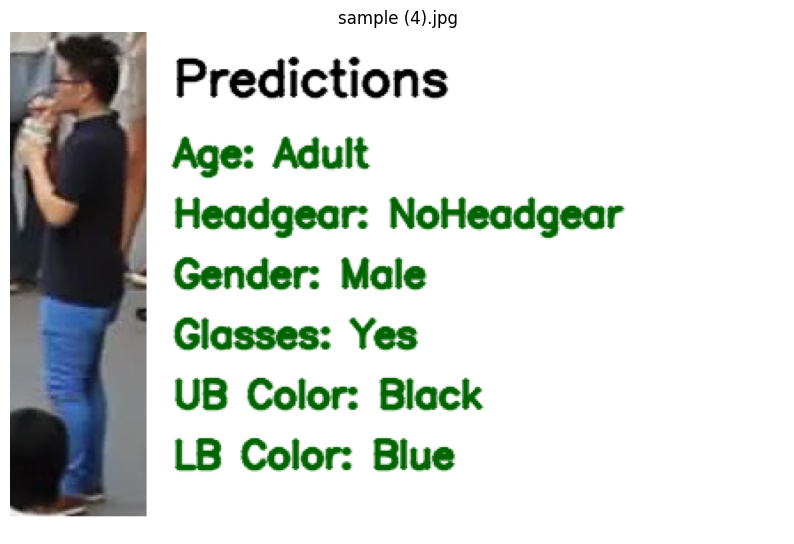

Saved annotated image: /content/sample (4)_annotated.jpg
{'Age': 'Adult', 'Headgear': 'NoHeadgear', 'Gender': 'Male', 'Glasses': 'Yes', 'UBClothingColor': 'Black', 'LBClothingColor': 'Blue'}


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from PIL import Image

external_paths = [f"/content/{name}" for name in uploaded.keys()]

@torch.no_grad()
def predict_single_image(model, image_path):
    image = np.array(Image.open(image_path).convert("RGB"))
    tensor = val_tfms(image=image)["image"].unsqueeze(0).to(device)

    outputs = model(tensor)
    preds = {}
    for key in outputs:
        pred_id = outputs[key].argmax(dim=1).cpu().numpy()[0]
        preds[key] = label_encoders[key].inverse_transform([pred_id])[0]

    # Convert binary numeric labels to readable text
    if "Gender" in preds:
        preds["Gender"] = "Male" if str(preds["Gender"]) == "0" else "Female"

    if "Glasses" in preds:
        preds["Glasses"] = "No" if str(preds["Glasses"]) == "0" else "Yes"

    return image, preds


for path in external_paths:
    image, preds = predict_single_image(model, path)

    lines = [
        "Predictions",
        f"Age: {preds['Age']}",
        f"Headgear: {preds['Headgear']}",
        f"Gender: {preds['Gender']}",
        f"Glasses: {preds['Glasses']}",
        f"UB Color: {preds['UBClothingColor']}",
        f"LB Color: {preds['LBClothingColor']}",
    ]

    h, w, _ = image.shape
    panel_width = 360
    top_margin = 25
    line_gap = 34
    bottom_margin = 20

    required_text_height = top_margin + line_gap * len(lines) + bottom_margin
    canvas_height = max(h, required_text_height)

    canvas = np.ones((canvas_height, w + panel_width, 3), dtype=np.uint8) * 255
    canvas[:h, :w] = image

    font = cv2.FONT_HERSHEY_SIMPLEX

    y = top_margin + 10
    cv2.putText(canvas, lines[0], (w + 15, y), font, 0.9, (0, 0, 0), 2, cv2.LINE_AA)
    y += 40

    for line in lines[1:]:
        cv2.putText(canvas, line, (w + 15, y), font, 0.7, (0, 100, 0), 2, cv2.LINE_AA)
        y += line_gap

    base, ext = os.path.splitext(path)
    out_path = f"{base}_annotated{ext}"
    Image.fromarray(canvas).save(out_path)

    plt.figure(figsize=(10, 8))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title(os.path.basename(path))
    plt.show()

    print("Saved annotated image:", out_path)
    print(preds)

## Validation summary

Please add a short written summary about:
- Which attributes were easiest / hardest?
- Did class imbalance affect results?
- What would you improve with more time?


## 13. Validation summary, discussion and reflection

### Approach
A single multi-task model was trained using a shared pretrained convolutional backbone and six task-specific classification heads. This satisfies the assignment requirement of predicting all attributes with one unified model rather than training separate models for each attribute.

### Model choice
A pretrained EfficientNet backbone was selected because it provides strong visual feature extraction while remaining efficient enough to train in Google Colab. Multi-task learning is a natural fit for person attribute recognition because many of the target attributes share useful visual cues, allowing the backbone to learn common representations across tasks.

### Preprocessing and augmentation
Images were resized to a fixed resolution and normalized using ImageNet statistics. Light augmentation was applied during training through horizontal flips, brightness/contrast perturbations, and small geometric transformations. These augmentations were chosen to improve generalization while keeping the pipeline simple, reproducible, and suitable for the assignment time budget.

### Evaluation summary
Performance was evaluated per attribute using:
- Accuracy
- Macro Recall
- Macro F1

These metrics provide a more balanced view than accuracy alone, especially for attributes where class imbalance may be present.

Final test performance was as follows:

| Attribute | Accuracy | Macro Recall | Macro F1 |
|---|---:|---:|---:|
| Age | 0.9913 | 0.9175 | 0.9359 |
| Headgear | 0.9911 | 0.8630 | 0.8742 |
| Gender | 0.9607 | 0.9602 | 0.9601 |
| Glasses | 0.9017 | 0.8325 | 0.8314 |
| UBClothingColor | 0.8623 | 0.8258 | 0.8208 |
| LBClothingColor | 0.8703 | 0.7734 | 0.7581 |

The overall **test mean macro F1 was 0.8634**.

### Which attributes were easiest and hardest?
Based on the final test results, **Age** and **Gender** were the easiest attributes overall. **Age** achieved the highest accuracy (**99.13%**), while **Gender** achieved the highest macro F1 (**0.9601**) with **96.07% accuracy**. This suggests that both tasks have relatively strong and learnable visual cues in the dataset.

The most challenging attributes were the more fine-grained appearance tasks, especially **Lower-body clothing color**, which had the lowest macro F1 (**0.7581**), followed by **Upper-body clothing color** (**0.8208**) and **Glasses** (**0.8314**). These tasks are harder because clothing color can be ambiguous under different lighting conditions, clothing regions may be partially occluded, and glasses often occupy only a very small image region.

Although **Headgear** had very high accuracy (**99.11%**), its macro F1 (**0.8742**) was noticeably lower than Age and Gender. This suggests that the model predicted dominant headgear classes very well, but performed less strongly on less frequent classes.

### Did class imbalance affect results?
Yes, class imbalance likely affected several attributes, particularly Headgear, Glasses, and the clothing color tasks.

The class distributions in the full dataset are shown below:

| Attribute | Class | Count |
|---|---|---:|
| Age | Adult | 65,422 |
| Age | Young | 3,550 |
| Age | Elderly | 1,028 |
| Headgear | NoHeadgear | 67,515 |
| Headgear | Cap | 1,662 |
| Headgear | Helmet | 679 |
| Headgear | Hat | 144 |
| Gender | 0 | 39,292 |
| Gender | 1 | 30,708 |
| Glasses | 0 | 57,504 |
| Glasses | 1 | 12,496 |
| UBClothingColor | White | 22,255 |
| UBClothingColor | Black | 19,476 |
| UBClothingColor | Grey | 10,645 |
| UBClothingColor | Blue | 4,950 |
| UBClothingColor | Red | 3,492 |
| UBClothingColor | Green | 2,066 |
| UBClothingColor | Brown | 1,932 |
| UBClothingColor | Pink | 1,735 |
| UBClothingColor | Yellow | 1,612 |
| UBClothingColor | Purple | 1,427 |
| UBClothingColor | Orange | 410 |
| LBClothingColor | Black | 40,869 |
| LBClothingColor | Blue | 11,107 |
| LBClothingColor | Grey | 8,440 |
| LBClothingColor | White | 3,621 |
| LBClothingColor | Brown | 2,970 |
| LBClothingColor | Pink | 1,125 |
| LBClothingColor | Green | 650 |
| LBClothingColor | Red | 498 |
| LBClothingColor | Yellow | 421 |
| LBClothingColor | Orange | 201 |
| LBClothingColor | Purple | 98 |

The dataset is clearly imbalanced. For example, **Age** is dominated by `Adult`, **Headgear** is overwhelmingly `NoHeadgear`, and the clothing color tasks contain several very rare classes such as `Orange` and `Purple`. This imbalance helps explain why some attributes achieve high overall accuracy but lower macro recall and macro F1, especially for **Headgear** and **LBClothingColor**. Macro recall and macro F1 are therefore important here because they provide a more balanced view of performance across both frequent and infrequent classes.

### Training behaviour
The model showed steady improvement across epochs. Validation mean F1 improved from **0.7957 in Epoch 1** to **0.8732 in Epoch 8**, indicating that the model continued learning useful features throughout training.

Some attributes improved more steadily than others:
- **Age** improved consistently and remained very strong throughout training.
- **Gender** stabilized relatively early and stayed robust.
- **Headgear**, **Glasses**, and clothing colors fluctuated more across epochs, which is expected for more fine-grained and potentially imbalanced visual categories.

The final selected checkpoint achieved the strongest overall validation mean F1 and generalized reasonably well to the test split.

### Failure modes
Likely failure cases include:
- occluded or very small glasses/headgear regions
- ambiguous age-group appearance
- confusing clothing colors under poor lighting
- low-resolution crops
- partial person visibility
- noisy labels for subjective attributes

### Trade-offs
This implementation prioritizes clarity, reproducibility, and robustness over heavy hyperparameter tuning. It is intended as a strong and understandable baseline rather than a maximally optimized system. A single shared-backbone model is also more practical for deployment and maintenance than multiple separate models.

### What I would improve with more time
With more time, I would improve the system in several ways:

1. **Class imbalance handling**  
   I would experiment with class-weighted cross-entropy or focal loss for attributes such as Headgear, Glasses, and clothing colors to improve minority-class performance.

2. **Better data splitting**  
   I would explore a multi-label stratified split so that the train, validation, and test sets better preserve the joint label distribution across attributes.

3. **Higher-resolution training**  
   Small objects such as glasses and fine headgear details may benefit from larger input sizes, such as 256×256 or 320×320.

4. **Stronger augmentation and regularization**  
   More targeted augmentation, including color jitter and occlusion-based augmentation, could improve robustness for clothing color and accessory-related tasks.

5. **Task-balanced loss weighting**  
   At the moment, all six task losses are summed equally. I would test attribute-specific weighting so that harder tasks receive more learning emphasis.

6. **Region-aware modeling**  
   Attributes such as headgear and glasses depend heavily on the head region, while clothing colors depend on torso and lower-body regions. A more advanced approach could use attention or region-aware features to better capture these localized cues.

## Test inference

Generate a CSV containing:
- `image_path`
- predicted labels


In [1]:
!git clone https://github.com/spaceman96-cyber/Person-Attribute-Recognition.git

Cloning into 'Person-Attribute-Recognition'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


In [3]:
!ls /content

Person-Attribute-Recognition  sample_data
